## Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(10,5)

## Datasets

In [3]:
customers = pd.read_csv(r"C:\Users\Nishant Lal\Downloads\archive\olist_customers_dataset.csv")
orders = pd.read_csv(r"C:\Users\Nishant Lal\Downloads\archive\olist_orders_dataset.csv")
items = pd.read_csv(r"C:\Users\Nishant Lal\Downloads\archive\olist_order_items_dataset.csv")
products = pd.read_csv(r"C:\Users\Nishant Lal\Downloads\archive\olist_products_dataset.csv")
payments = pd.read_csv(r"C:\Users\Nishant Lal\Downloads\archive\olist_order_payments_dataset.csv")
category = pd.read_csv(r"C:\Users\Nishant Lal\Downloads\archive\product_category_name_translation.csv")

## Dataset Overview

In [4]:
print(customers.shape)
print(orders.shape)
print(items.shape)
print(products.shape)
print(payments.shape)

(99441, 5)
(99441, 8)
(112650, 7)
(32951, 9)
(103886, 5)


In [5]:
customers.info()
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4

In [6]:
customers.isnull().sum()
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

## Merging Data

In [7]:
df = orders.merge(customers,on="customer_id")
df = df.merge(items,on="order_id")
df = df.merge(products,on="product_id")
df = df.merge(payments,on="order_id")
df = df.merge(category,on="product_category_name",how="left")

In [8]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,500.0,19.0,8.0,13.0,1,credit_card,1,18.12,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,500.0,19.0,8.0,13.0,3,voucher,1,2.00,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,500.0,19.0,8.0,13.0,2,voucher,1,18.59,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,1.0,400.0,19.0,13.0,19.0,1,boleto,1,141.46,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1.0,420.0,24.0,19.0,21.0,1,credit_card,3,179.12,auto


## Visualization

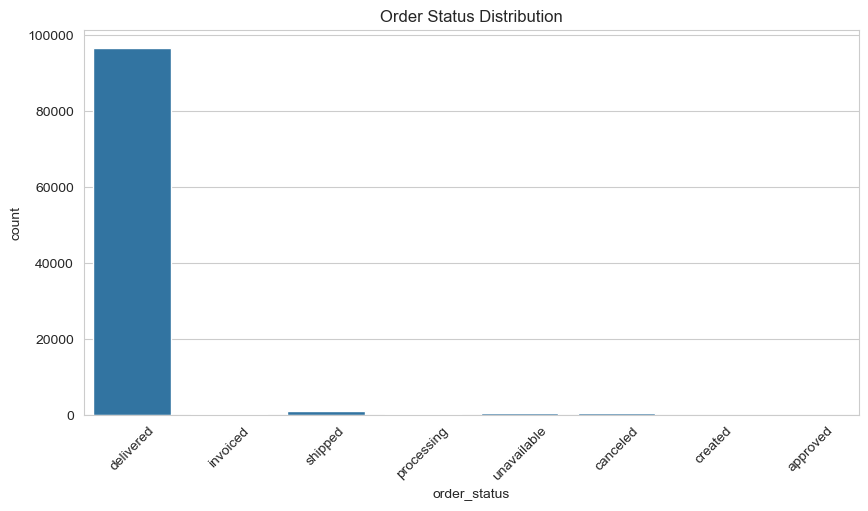

In [9]:
#Order Status Distribution
sns.countplot(x="order_status",data=orders)
plt.xticks(rotation=45)
plt.title("Order Status Distribution")
plt.show()

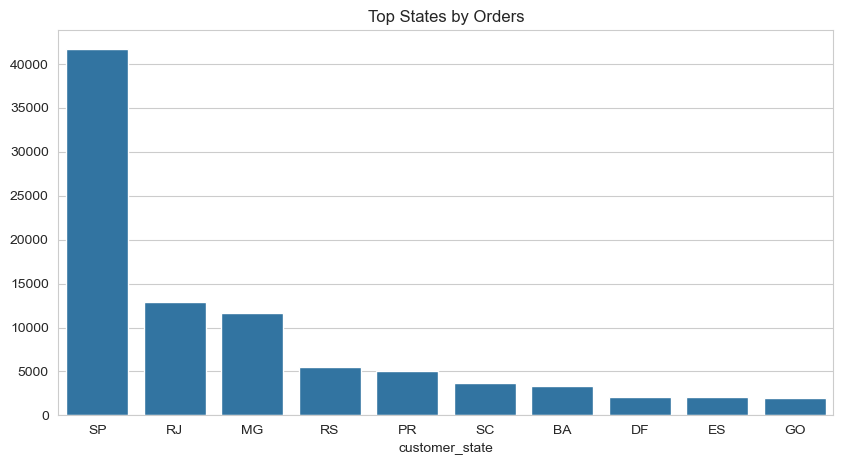

In [10]:
#Top 10 States by Orders
top_states = customers["customer_state"].value_counts().head(10)

sns.barplot(
    x=top_states.index,
    y=top_states.values
)

plt.title("Top States by Orders")
plt.show()

In [14]:
#Monthly Sales Trend
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)
df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"]
)

df["month"] = df["order_purchase_timestamp"].dt.to_period("M")

In [15]:
monthly_sales = df.groupby("month")["payment_value"].sum()

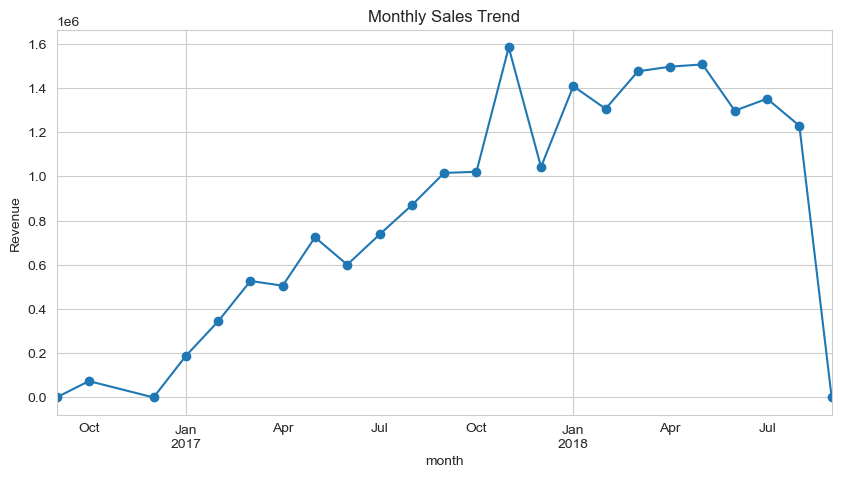

In [16]:
monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.ylabel("Revenue")
plt.show()

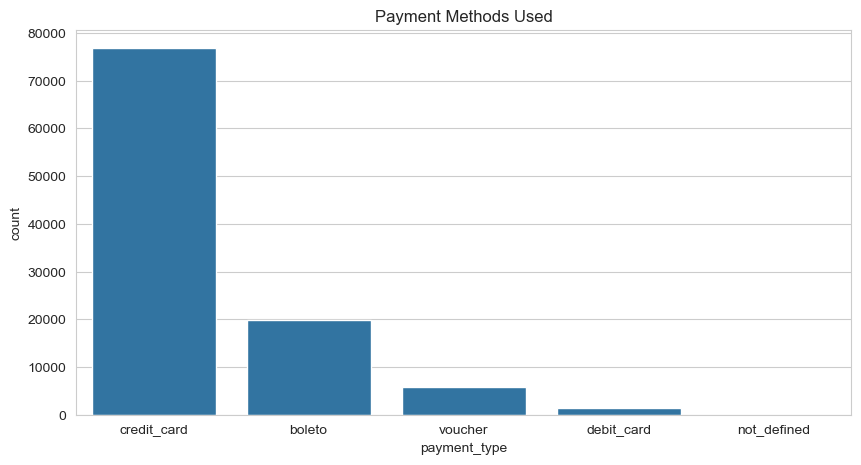

In [17]:
#Payment Methods
sns.countplot(
    x="payment_type",
    data=payments
)

plt.title("Payment Methods Used")
plt.show()

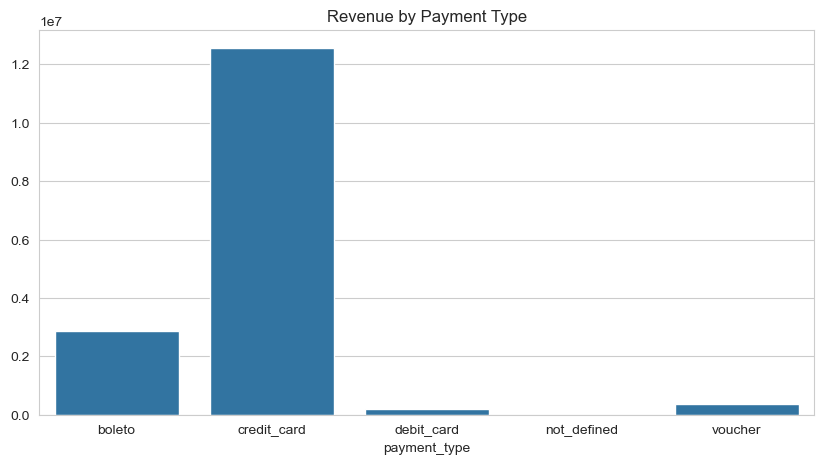

In [18]:
#Revenue by Payment Type
revenue = payments.groupby("payment_type")["payment_value"].sum()

sns.barplot(
    x=revenue.index,
    y=revenue.values
)

plt.title("Revenue by Payment Type")
plt.show()

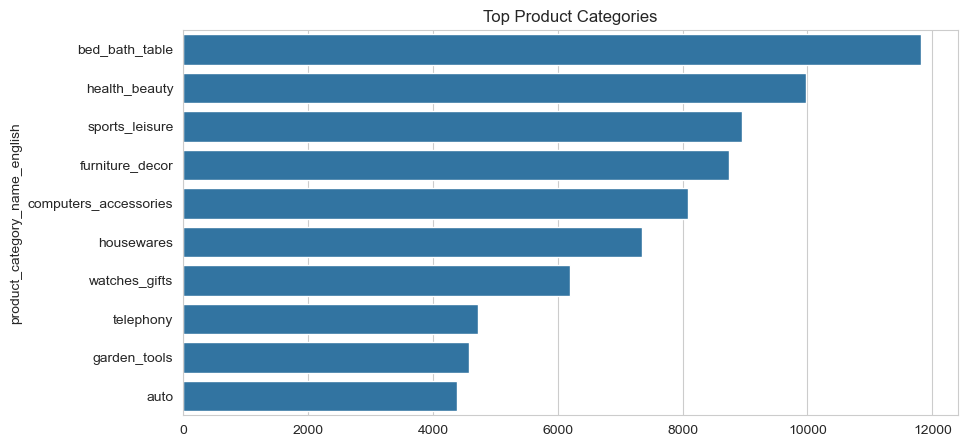

In [19]:
#Top Product Categories
top_cat = df["product_category_name_english"].value_counts().head(10)

sns.barplot(
    y=top_cat.index,
    x=top_cat.values
)

plt.title("Top Product Categories")
plt.show()

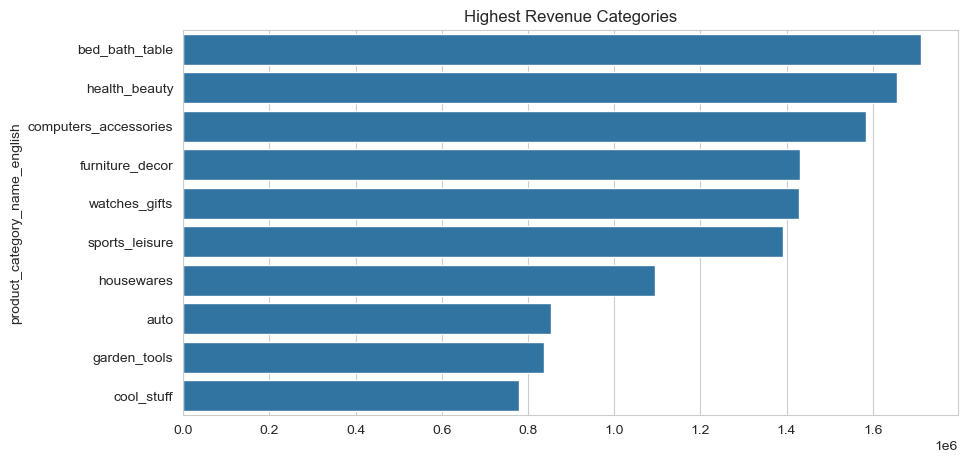

In [20]:
#Top Categories by Revenue
cat_sales = df.groupby(
    "product_category_name_english"
)["payment_value"].sum().sort_values(ascending=False).head(10)

sns.barplot(
    x=cat_sales.values,
    y=cat_sales.index
)

plt.title("Highest Revenue Categories")
plt.show()

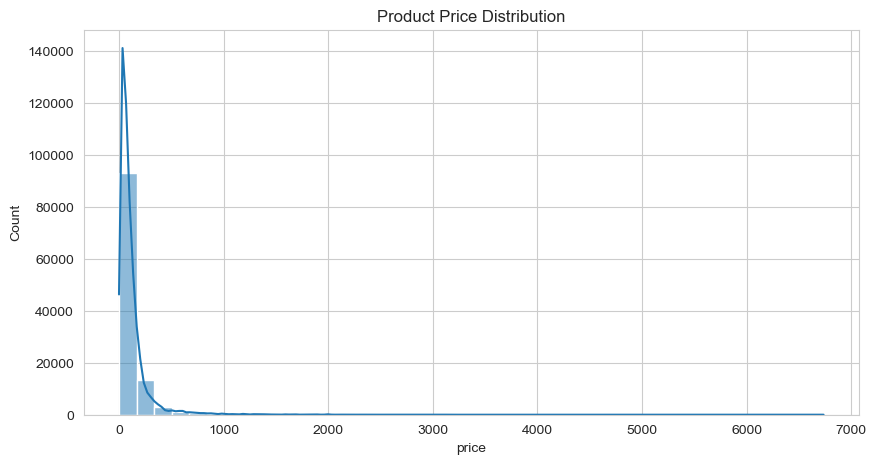

In [21]:
#Distribution of Product Prices
sns.histplot(
    items["price"],
    bins=40,
    kde=True
)

plt.title("Product Price Distribution")
plt.show()

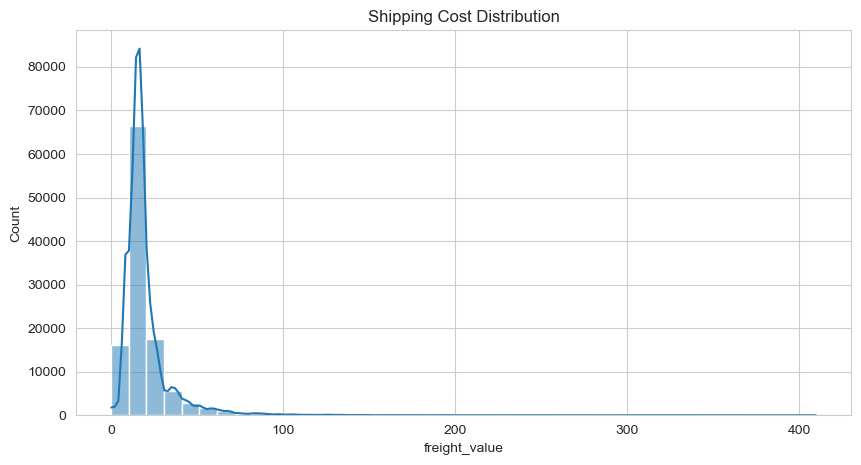

In [22]:
#Shipping Cost Distribution
sns.histplot(
    items["freight_value"],
    bins=40,
    kde=True
)

plt.title("Shipping Cost Distribution")
plt.show()

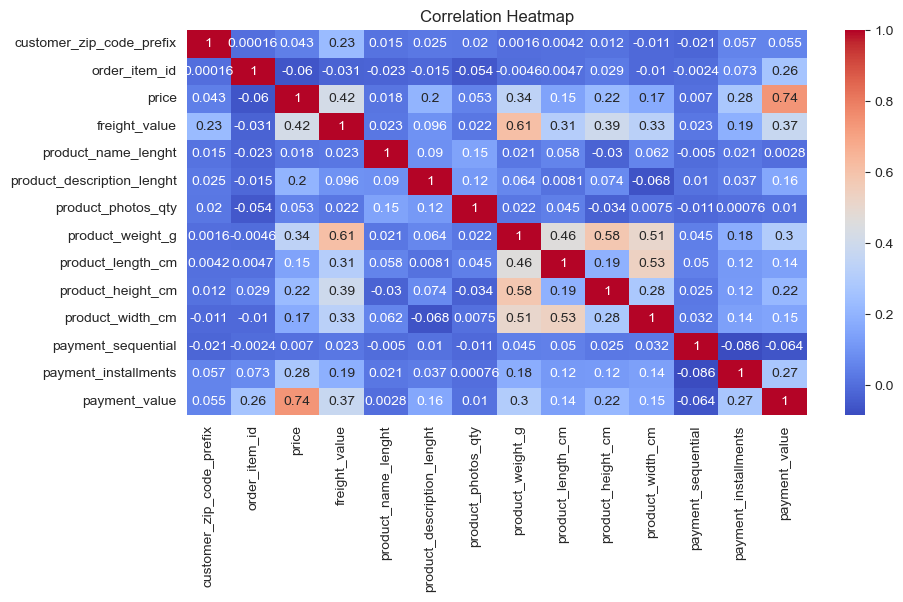

In [23]:
#Correlation Heatmap
num_cols = df.select_dtypes(include=np.number)

sns.heatmap(
    num_cols.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

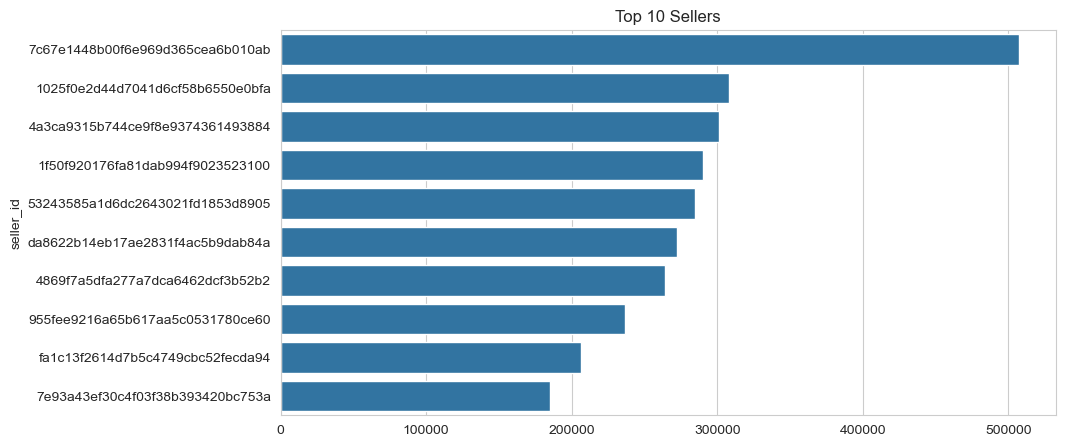

In [24]:
#Top Sellers
seller_sales = df.groupby(
    "seller_id"
)["payment_value"].sum().sort_values(ascending=False).head(10)

sns.barplot(
    x=seller_sales.values,
    y=seller_sales.index
)

plt.title("Top 10 Sellers")
plt.show()

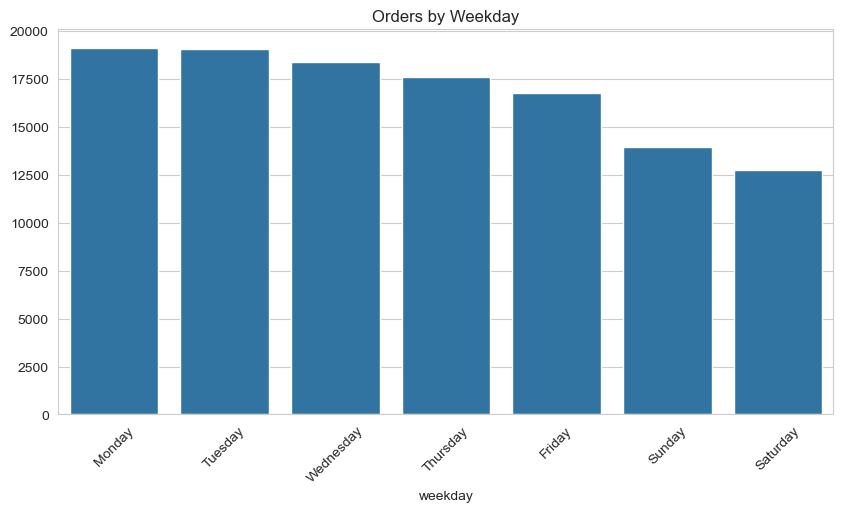

In [25]:
#Orders by Weekday
df["weekday"] = df["order_purchase_timestamp"].dt.day_name()

order_day = df["weekday"].value_counts()

sns.barplot(
    x=order_day.index,
    y=order_day.values
)

plt.xticks(rotation=45)
plt.title("Orders by Weekday")
plt.show()

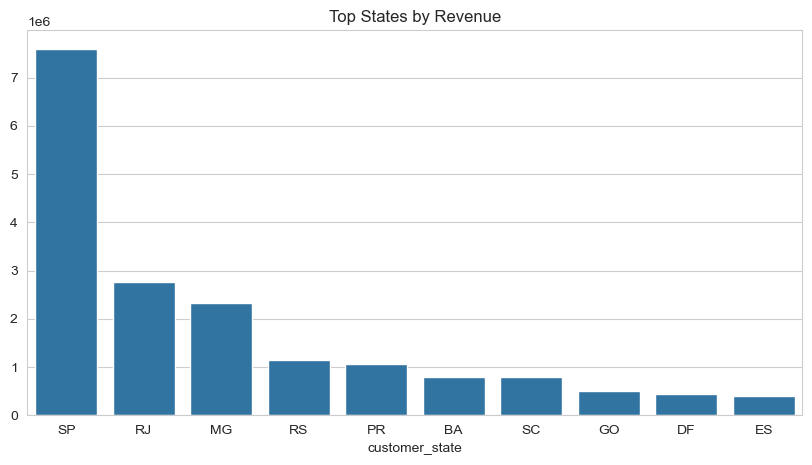

In [26]:
#State-wise Revenue
state_rev = df.groupby(
    "customer_state"
)["payment_value"].sum().sort_values(ascending=False).head(10)

sns.barplot(
    x=state_rev.index,
    y=state_rev.values
)

plt.title("Top States by Revenue")
plt.show()

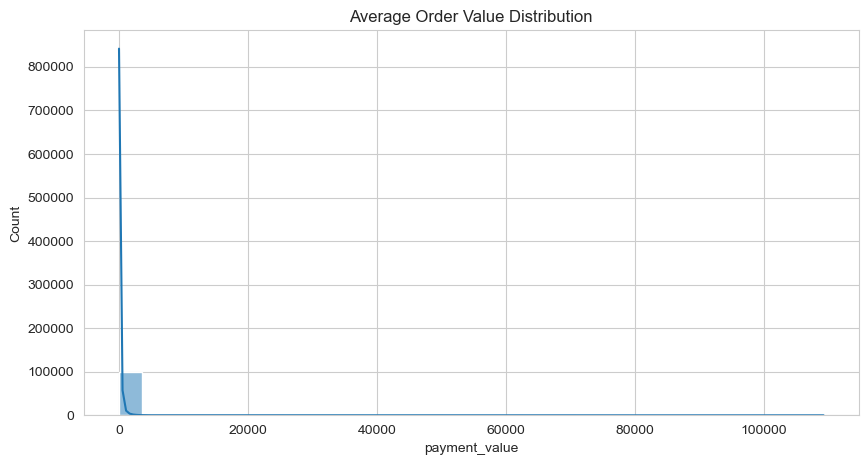

In [27]:
#Average Order Value
aov = df.groupby("order_id")["payment_value"].sum()

sns.histplot(aov,bins=30,kde=True)

plt.title("Average Order Value Distribution")
plt.show()

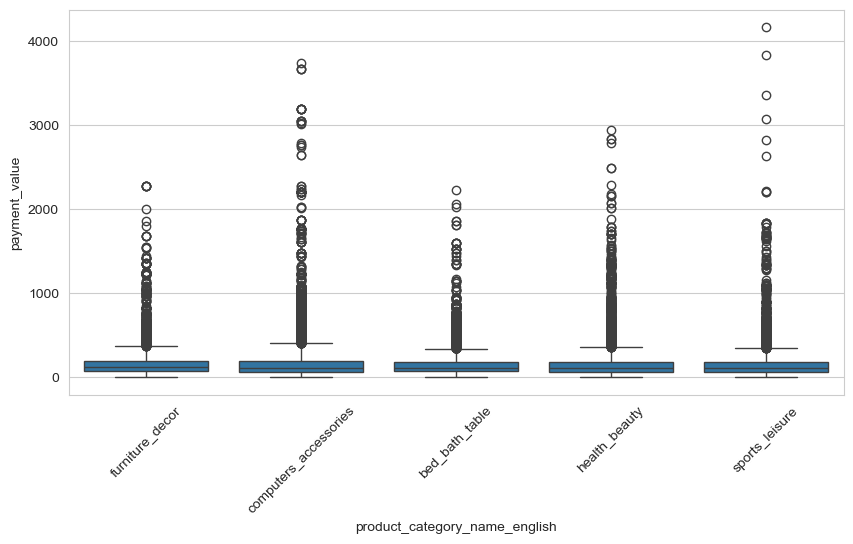

In [28]:
#Boxplot of Category Revenue
top5 = df[
    df["product_category_name_english"].isin(
        df["product_category_name_english"]
        .value_counts()
        .head(5)
        .index
    )
]

sns.boxplot(
    x="product_category_name_english",
    y="payment_value",
    data=top5
)

plt.xticks(rotation=45)
plt.show()